# Simple Linear Regression: Predict Salary from Years of Experience

This notebook demonstrates a simple linear regression model that predicts employee salary based on years of experience. It follows the required structure: Problem Statement, Understanding of Dataset, Theory, Math, Workflow Diagram, Pseudocode, Expected/Obtained Output. Implementation includes data cleaning, EDA, feature scaling, feature engineering, and evaluation metrics.

**Note:** If you receive a different CSV in the exam, change the `DATA_PATH`, `FEATURE_COL`, and `TARGET_COL` variables in the imports cell accordingly.

In [1]:
# Imports and Synthetic CSV Generation
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

# Change these if your exam CSV uses different column names
DATA_PATH = "salary_experience.csv"
FEATURE_COL = "experience"
TARGET_COL = "salary"

# Create synthetic dataset and save to CSV if it doesn't exist
if not os.path.exists(DATA_PATH):
    np.random.seed(42)
    n = 180
    experience = np.round(np.random.uniform(0, 30, n), 2)
    salary = 30000 + 2500*experience + np.random.normal(0, 5000, n)
    salary = np.clip(salary, 30000, 150000)
    df_sample = pd.DataFrame({FEATURE_COL: experience, TARGET_COL: salary})
    df_sample.to_csv(DATA_PATH, index=False)
    print(f"✓ Sample CSV created: {DATA_PATH} with {n} samples")
else:
    print(f"✓ Found existing {DATA_PATH}, will use it")

print(f"\nFirst 5 rows of {DATA_PATH}:")
print(pd.read_csv(DATA_PATH).head())

✓ Sample CSV created: salary_experience.csv with 180 samples

First 5 rows of salary_experience.csv:
   experience        salary
0       11.24  54183.733538
1       28.52  99689.692419
2       21.96  88967.586087
3       17.96  68745.678418
4        4.68  42837.299673


## 1. Problem Statement

**Objective:** Build a simple linear regression model to predict employee salary based on years of experience.

**Features:**
- **Experience** (years): Years of work experience

**Target:**
- **Salary** ($/year): Annual salary

**Expected Output:** A trained model with predictions on test data and performance metrics including MSE, RMSE, MAE, and R² score.

## 2. Understanding of Dataset

Load the CSV file and display basic information about the dataset.

In [2]:
df = pd.read_csv(DATA_PATH)

print("="*60)
print("DATASET OVERVIEW")
print("="*60)
print("\nFirst 10 rows:")
print(df.head(10))

print(f"\nDataset shape: {df.shape}")
print(f"Samples: {df.shape[0]}, Features: {df.shape[1]}")

print("\nColumn names and data types:")
print(df.dtypes)

print("\nStatistical Summary:")
print(df.describe().T)

DATASET OVERVIEW

First 10 rows:
   experience        salary
0       11.24  54183.733538
1       28.52  99689.692419
2       21.96  88967.586087
3       17.96  68745.678418
4        4.68  42837.299673
5        4.68  48235.713771
6        1.74  30000.000000
7       25.99  95898.169293
8       18.03  76374.413971
9       21.24  87009.114359

Dataset shape: (180, 2)
Samples: 180, Features: 2

Column names and data types:
experience    float64
salary        float64
dtype: object

Statistical Summary:
            count          mean           std       min           25%  \
experience  180.0     14.163667      8.821322      0.17      6.587500   
salary      180.0  65894.877219  22572.595939  30000.00  46786.452549   

                     50%           75%            max  
experience     13.925000     21.875000      29.610000  
salary      64168.475387  86100.548452  111800.845833  


## 3. Data Cleaning

Check for and handle missing values, duplicates, and invalid values.

In [3]:
print("="*60)
print("DATA CLEANING")
print("="*60)

# Check for missing values
print("\n1. Missing Values Check:")
missing = df.isnull().sum()
print(f"   Missing values per column:\n{missing}")
if missing.sum() == 0:
    print("   ✓ No missing values found")
else:
    df = df.dropna()

# Check for duplicates
print("\n2. Duplicate Rows Check:")
dupes = df.duplicated().sum()
print(f"   Duplicate rows: {dupes}")
if dupes > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"   × Removed {dupes} duplicate(s)")
else:
    print("   ✓ No duplicates found")

# Check for invalid values
print("\n3. Invalid Values Check:")
invalid_exp = (df[FEATURE_COL] < 0).sum() + (df[FEATURE_COL] > 50).sum()
invalid_sal = (df[TARGET_COL] < 0).sum()
print(f"   Invalid experience: {invalid_exp}")
print(f"   Invalid salary: {invalid_sal}")

df = df[(df[FEATURE_COL] >= 0) & (df[FEATURE_COL] <= 50) & (df[TARGET_COL] > 0)]
df = df.reset_index(drop=True)
print(f"\nDataset shape after cleaning: {df.shape}")

DATA CLEANING

1. Missing Values Check:
   Missing values per column:
experience    0
salary        0
dtype: int64
   ✓ No missing values found

2. Duplicate Rows Check:
   Duplicate rows: 0
   ✓ No duplicates found

3. Invalid Values Check:
   Invalid experience: 0
   Invalid salary: 0

Dataset shape after cleaning: (180, 2)


## 4. Exploratory Data Analysis (EDA)

Visualize the relationship between experience and salary.

EXPLORATORY DATA ANALYSIS


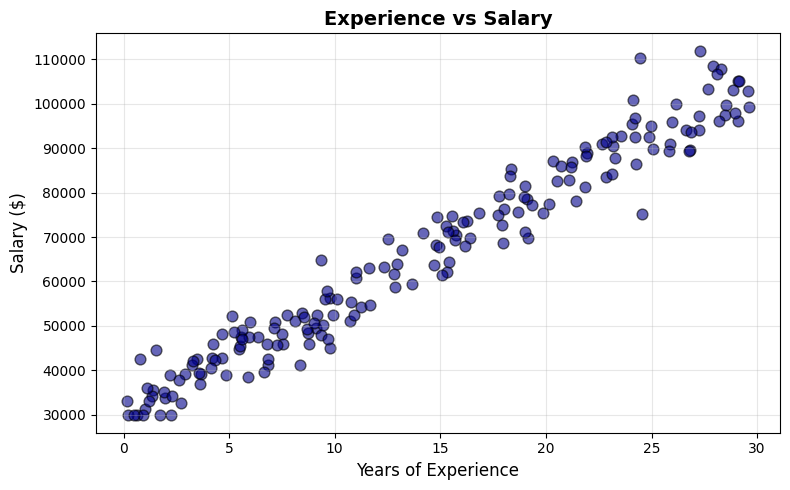

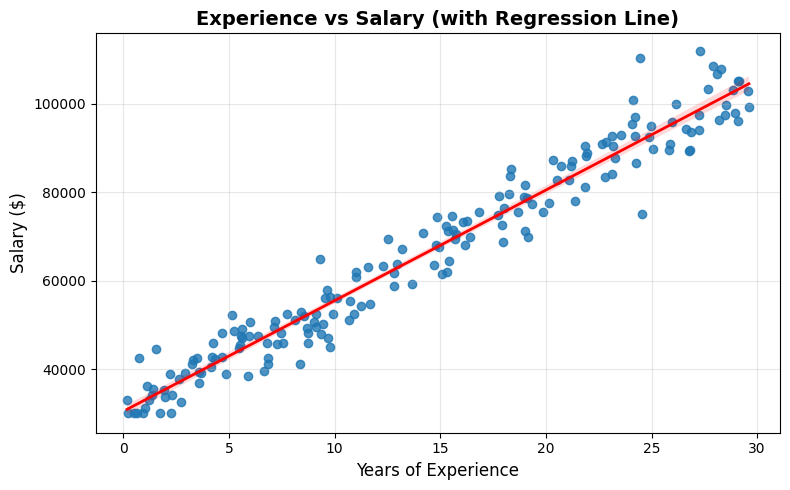


Pearson Correlation: 0.9769
→ Strong positive correlation (excellent for linear regression)


In [4]:
print("="*60)
print("EXPLORATORY DATA ANALYSIS")
print("="*60)

# Scatter plot
plt.figure(figsize=(8, 5))
plt.scatter(df[FEATURE_COL], df[TARGET_COL], alpha=0.6, color='darkblue', edgecolors='black', s=60)
plt.xlabel('Years of Experience', fontsize=12)
plt.ylabel('Salary ($)', fontsize=12)
plt.title('Experience vs Salary', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Regression plot
plt.figure(figsize=(8, 5))
sns.regplot(data=df, x=FEATURE_COL, y=TARGET_COL, line_kws={"color": "red", "linewidth": 2})
plt.xlabel('Years of Experience', fontsize=12)
plt.ylabel('Salary ($)', fontsize=12)
plt.title('Experience vs Salary (with Regression Line)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Correlation
corr = df[[FEATURE_COL, TARGET_COL]].corr().iloc[0, 1]
print(f"\nPearson Correlation: {corr:.4f}")
if corr > 0.7:
    print("→ Strong positive correlation (excellent for linear regression)")
elif corr > 0.5:
    print("→ Moderate positive correlation (good for linear regression)")

## 5. Feature Engineering & Scaling

Prepare features and normalize using StandardScaler.

In [5]:
print("="*60)
print("FEATURE ENGINEERING & SCALING")
print("="*60)

# Extract features and target
X = df[[FEATURE_COL]].values
y = df[TARGET_COL].values

print(f"\nFeature matrix (X) shape: {X.shape}")
print(f"Target vector (y) shape: {y.shape}")

# Apply scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\nOriginal X (first 5): {X[:5].ravel()}")
print(f"Scaled X (first 5): {X_scaled[:5].ravel()}")
print(f"\nScaler mean: {scaler.mean_[0]:.2f}")
print(f"Scaler scale (std): {scaler.scale_[0]:.2f}")

FEATURE ENGINEERING & SCALING

Feature matrix (X) shape: (180, 1)
Target vector (y) shape: (180,)

Original X (first 5): [11.24 28.52 21.96 17.96  4.68]
Scaled X (first 5): [-0.33235629  1.63199784  0.88627081  0.43155921 -1.07808332]

Scaler mean: 14.16
Scaler scale (std): 8.80


## 6. Theory: Simple Linear Regression

Simple Linear Regression models a linear relationship between one input feature (years of experience) and a continuous target output (salary).

**Equation:** Salary = m × Experience + b
- m = slope (salary increase per year of experience)
- b = intercept (base salary)

The model minimizes Mean Squared Error (MSE) to find optimal m and b:

**MSE = (1/n) × Σ(Actual_Salary - Predicted_Salary)²**

## 7. Workflow Diagram

WORKFLOW DIAGRAM


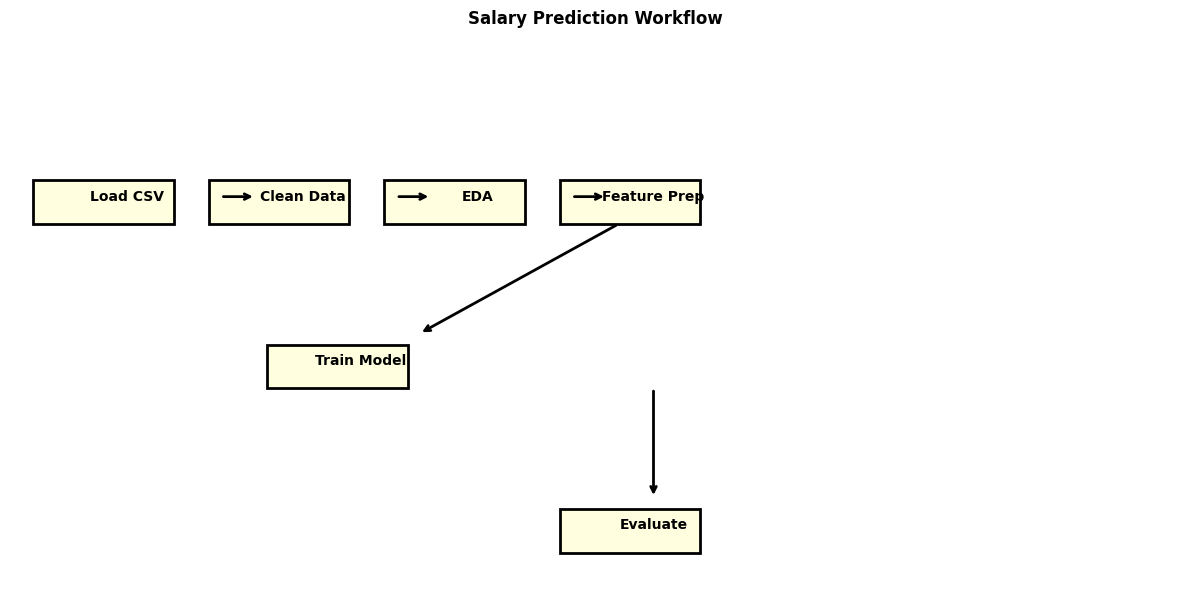

In [6]:
print("="*60)
print("WORKFLOW DIAGRAM")
print("="*60)

fig, ax = plt.subplots(figsize=(12, 6))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

from matplotlib.patches import Rectangle
workflow_steps = [
    (0.1, 0.7, "Load CSV"),
    (0.25, 0.7, "Clean Data"),
    (0.4, 0.7, "EDA"),
    (0.55, 0.7, "Feature Prep"),
    (0.3, 0.4, "Train Model"),
    (0.55, 0.1, "Evaluate"),
]

for step_x, step_y, label in workflow_steps:
    rect = Rectangle((step_x-0.08, step_y-0.05), 0.12, 0.08, 
                      facecolor='lightyellow', edgecolor='black', linewidth=2)
    ax.add_patch(rect)
    ax.text(step_x, step_y, label, ha='center', va='center', fontsize=10, fontweight='bold')

# Arrows
arrows = [((0.18, 0.7), (0.21, 0.7)), ((0.33, 0.7), (0.36, 0.7)), ((0.48, 0.7), (0.51, 0.7)),
          ((0.52, 0.65), (0.35, 0.45)), ((0.55, 0.35), (0.55, 0.15))]

for start, end in arrows:
    ax.annotate('', xy=end, xytext=start, arrowprops=dict(arrowstyle='->', lw=2, color='black'))

ax.set_title('Salary Prediction Workflow', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Pseudocode

```
ALGORITHM: Simple Linear Regression (Salary Prediction)

INPUT: DataFrame with feature (experience) and target (salary)
OUTPUT: Trained model, predictions, and evaluation metrics

1. Load CSV file containing experience and salary columns
2. Clean data: Remove missing values, duplicates, outliers
3. Extract feature X (experience) and target y (salary)
4. Apply StandardScaler to normalize X
5. Split data: X_train (80%), X_test (20%)
6. Initialize LinearRegression model
7. Train model: model.fit(X_train, y_train)
8. Make predictions: y_pred = model.predict(X_test)
9. Calculate metrics: MSE, RMSE, MAE, R²
10. Visualize: Actual vs Predicted, Residuals
11. Save model and scaler using joblib
```

## 9. Train-Test Split and Model Training

In [7]:
print("="*60)
print("TRAIN-TEST SPLIT AND MODEL TRAINING")
print("="*60)

# Split data: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f"\nTrain set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

print(f"\nModel trained successfully!")
print(f"Learned slope (m): {model.coef_[0]:.4f}")
print(f"Learned intercept (b): {model.intercept_:.2f}")
print(f"\nInterpretation:")
print(f"  Base Salary: ${model.intercept_:.2f}")
print(f"  Salary Increase per Year: ${model.coef_[0]:.2f}")

TRAIN-TEST SPLIT AND MODEL TRAINING

Train set size: 144 samples
Test set size: 36 samples

Model trained successfully!
Learned slope (m): 22206.6026
Learned intercept (b): 66143.22

Interpretation:
  Base Salary: $66143.22
  Salary Increase per Year: $22206.60


## 10. Model Evaluation

In [8]:
print("="*60)
print("MODEL EVALUATION")
print("="*60)

# Predictions
y_pred_train = model.predict(X_train)
y_pred = model.predict(X_test)

# Metrics
mse_train = mean_squared_error(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred)
rmse_test = np.sqrt(mse_test)
mae_test = mean_absolute_error(y_test, y_pred)
r2_test = r2_score(y_test, y_pred)

print("\nTraining Set Metrics:")
print(f"  MSE (Train): {mse_train:,.2f}")

print("\nTest Set Evaluation Metrics:")
print(f"  MSE (Mean Squared Error):   {mse_test:,.2f}")
print(f"  RMSE (Root Mean Squared):   {rmse_test:,.2f}")
print(f"  MAE (Mean Absolute Error):  {mae_test:,.2f}")
print(f"  R² Score:                   {r2_test:.4f}")

if r2_test > 0.9:
    print(f"\n✓ Excellent fit! Model explains {r2_test*100:.1f}% of variance")
elif r2_test > 0.7:
    print(f"\n✓ Good fit! Model explains {r2_test*100:.1f}% of variance")

# Sample predictions
print("\nSample Predictions (first 8 test samples):")
print(f"{'Actual':<15} {'Predicted':<15} {'Error':<15}")
print("-"*45)
for i in range(min(8, len(y_test))):
    error = abs(y_test[i] - y_pred[i])
    print(f"${y_test[i]:<14.2f} ${y_pred[i]:<14.2f} ${error:<14.2f}")

MODEL EVALUATION

Training Set Metrics:
  MSE (Train): 23,195,820.00

Test Set Evaluation Metrics:
  MSE (Mean Squared Error):   23,478,984.40
  RMSE (Root Mean Squared):   4,845.51
  MAE (Mean Absolute Error):  3,617.06
  R² Score:                   0.9492

✓ Excellent fit! Model explains 94.9% of variance

Sample Predictions (first 8 test samples):
Actual          Predicted       Error          
---------------------------------------------
$48278.24       $52451.72       $4173.47       
$31251.72       $32988.59       $1736.88       
$63586.50       $67446.65       $3860.15       
$55298.65       $57525.76       $2227.11       
$36085.65       $33190.55       $2895.11       
$45482.24       $44272.66       $1209.58       
$59326.59       $64922.25       $5595.66       
$30000.00       $36043.12       $6043.12       


## 11. Visualizations and Model Save

OBTAINED OUTPUT - VISUALIZATIONS


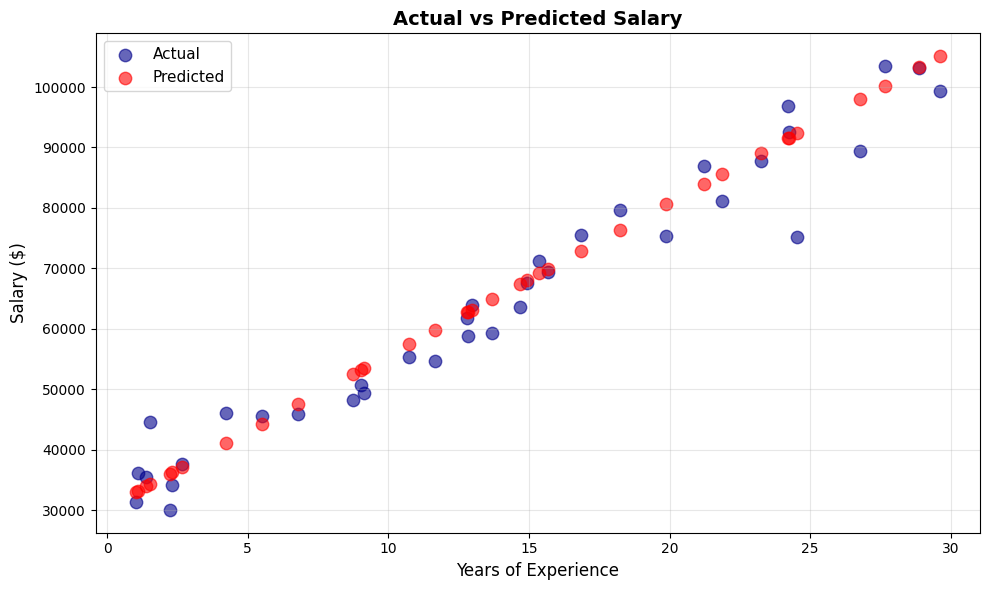

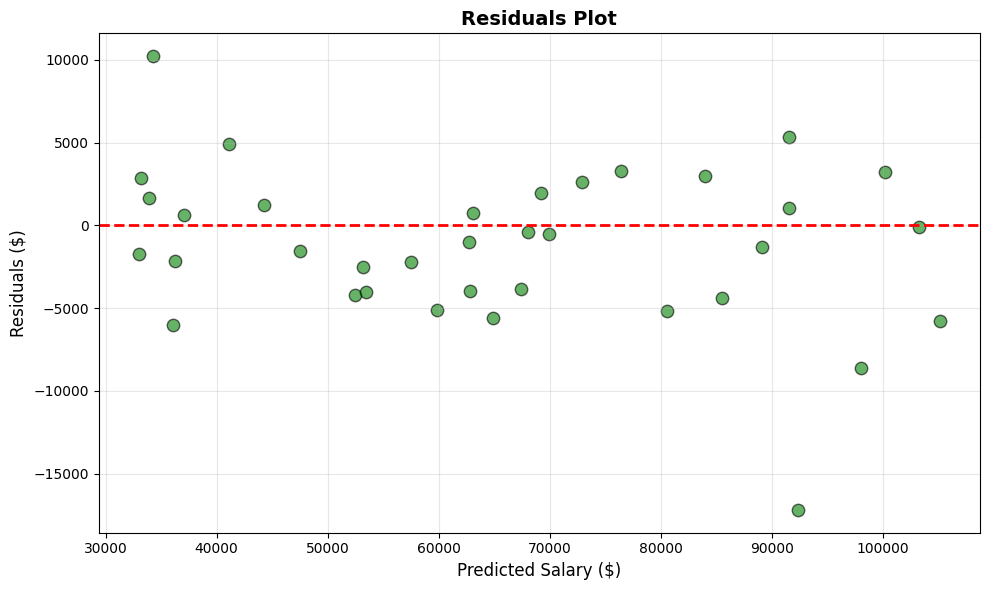


✓ Model and scaler saved successfully

FINAL SUMMARY
  Training Samples: 144
  Test Samples: 36
  Correlation: 0.9769
  Slope ($/year): 22206.60
  Intercept (Base $): 66143.22
  MSE: 23,478,984.40
  RMSE: 4,845.51
  R² Score: 0.9492


In [9]:
print("="*60)
print("OBTAINED OUTPUT - VISUALIZATIONS")
print("="*60)

# Actual vs Predicted
plt.figure(figsize=(10, 6))
plt.scatter(scaler.inverse_transform(X_test), y_test, color='darkblue', label='Actual', alpha=0.6, s=80)
plt.scatter(scaler.inverse_transform(X_test), y_pred, color='red', label='Predicted', alpha=0.6, s=80)
plt.xlabel('Years of Experience', fontsize=12)
plt.ylabel('Salary ($)', fontsize=12)
plt.title('Actual vs Predicted Salary', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Residuals plot
residuals = y_test - y_pred
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, color='green', alpha=0.6, s=80, edgecolors='black')
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.xlabel('Predicted Salary ($)', fontsize=12)
plt.ylabel('Residuals ($)', fontsize=12)
plt.title('Residuals Plot', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Save model
joblib.dump(model, '4_salary_model.joblib')
joblib.dump(scaler, '4_salary_scaler.joblib')
print("\n✓ Model and scaler saved successfully")

print(f"\n" + "="*60)
print("FINAL SUMMARY")
print("="*60)
print(f"  Training Samples: {X_train.shape[0]}")
print(f"  Test Samples: {X_test.shape[0]}")
print(f"  Correlation: {corr:.4f}")
print(f"  Slope ($/year): {model.coef_[0]:.2f}")
print(f"  Intercept (Base $): {model.intercept_:.2f}")
print(f"  MSE: {mse_test:,.2f}")
print(f"  RMSE: {rmse_test:,.2f}")
print(f"  R² Score: {r2_test:.4f}")
print("="*60)

# Predict Salary from Years of Experience

Simple Linear Regression predicting salary (continuous) from years of experience. Notebook creates `salary_experience.csv`, cleans data, performs EDA, trains model, evaluates, and saves artifacts.

   experience        salary
0       11.24  54183.733538
1       28.52  99689.692419
2       21.96  88967.586087
3       17.96  68745.678418
4        4.68  42837.299673


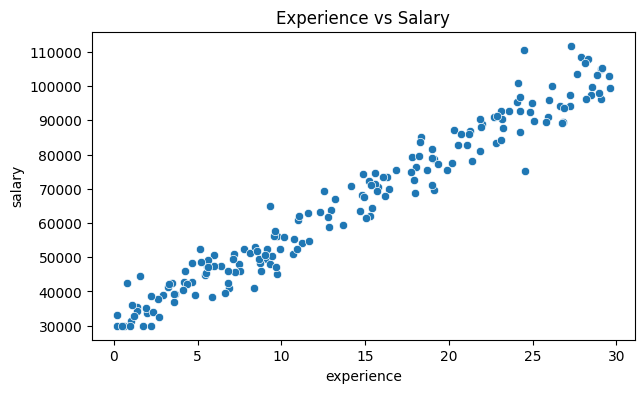

MSE: 23478984.402524557
R2: 0.9491590751792506
Saved model and scaler


In [10]:
# Salary vs Experience - simple dataset and SLR
import os
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

DATA_PATH = 'salary_experience.csv'
FEATURE_COL = 'experience'
TARGET_COL = 'salary'

if not os.path.exists(DATA_PATH):
    np.random.seed(2)
    n = 120
    exp = np.round(np.random.uniform(0, 20, n),2)
    salary = 3000 * exp + 20000 + np.random.normal(0, 8000, n)
    pd.DataFrame({FEATURE_COL: exp, TARGET_COL: salary}).to_csv(DATA_PATH, index=False)

df = pd.read_csv(DATA_PATH)
print(df.head())

# Cleaning
df = df[(df[FEATURE_COL] >= 0) & (df[TARGET_COL] > 0)].reset_index(drop=True)

# EDA
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(7,4))
sns.scatterplot(data=df, x=FEATURE_COL, y=TARGET_COL)
plt.title('Experience vs Salary')
plt.show()

# Feature prep and train
aX = df[[FEATURE_COL]].values
y = df[TARGET_COL].values
scaler = StandardScaler(); Xs = scaler.fit_transform(aX)
X_train, X_test, y_train, y_test = train_test_split(Xs, y, test_size=0.2, random_state=42)
model = LinearRegression().fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
print('MSE:', mean_squared_error(y_test, y_pred))
print('R2:', r2_score(y_test, y_pred))

joblib.dump(model, '4_salary_model.joblib')
joblib.dump(scaler, '4_scaler.joblib')
print('Saved model and scaler')

# For exam: set DATA_PATH/FEATURE_COL/TARGET_COL to match provided CSV.